In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error


#### Load the Dataset and performed basic exploration

In [2]:
df = pd.read_excel('premiums_with_life_style.xlsx')

print("The Shape of the Dataset: ", df.shape)

The Shape of the Dataset:  (10000, 15)


In [3]:
df.head()

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [4]:
# Checking for Null Values
df.isna().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Physical_Activity         0
Stress_Level              0
Number Of Dependants      0
BMI_Category              0
Smoking_Status            9
Employment_Status         7
Income_Level             18
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [5]:
# Since Null values are very less as compared to size of the data, we will drop the rows with null values

df.dropna(axis=0, inplace=True)

df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Physical_Activity        0
Stress_Level             0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

In [6]:
df.shape

(9973, 15)

In [7]:
# modyfying column names to have consistent naming format
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [8]:
df.dtypes

age                      int64
gender                     str
region                     str
marital_status             str
physical_activity          str
stress_level               str
number_of_dependants     int64
bmi_category               str
smoking_status             str
employment_status          str
income_level               str
income_lakhs             int64
medical_history            str
insurance_plan             str
annual_premium_amount    int64
dtype: object

In [9]:
numerical_cols = df.drop('annual_premium_amount', axis=1).select_dtypes(include=['int64']).columns
categorical_cols = df.select_dtypes(include='str').columns

In [10]:
numerical_cols, categorical_cols

(Index(['age', 'number_of_dependants', 'income_lakhs'], dtype='str'),
 Index(['gender', 'region', 'marital_status', 'physical_activity',
        'stress_level', 'bmi_category', 'smoking_status', 'employment_status',
        'income_level', 'medical_history', 'insurance_plan'],
       dtype='str'))

In [11]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

#### Perform Analysis and Outlier Treatment on Numerical columns

In [12]:
df[numerical_cols].describe()

,age,number_of_dependants,income_lakhs
count,9973.000000,9973.000000,9973.000000
mean,41.319362,3.195628,23.382232
std,58.044687,21.679565,32.334811
min,18.000000,0.000000,1.000000
25%,24.000000,0.000000,6.000000
50%,37.000000,2.000000,16.000000
75%,50.000000,3.000000,31.000000
max,1178.000000,456.000000,960.000000


In [13]:
# Plotting Box plot and distribution chart for Numerical columns
import seaborn as sns
from matplotlib import pyplot as plt

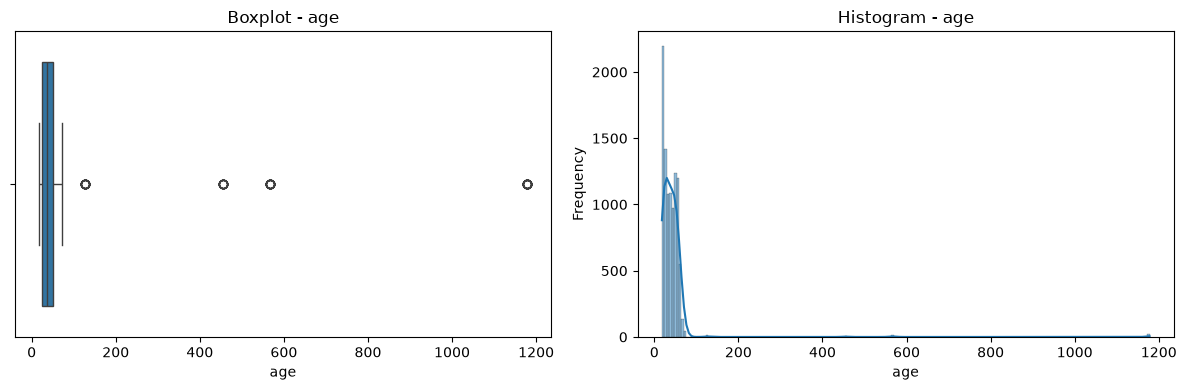

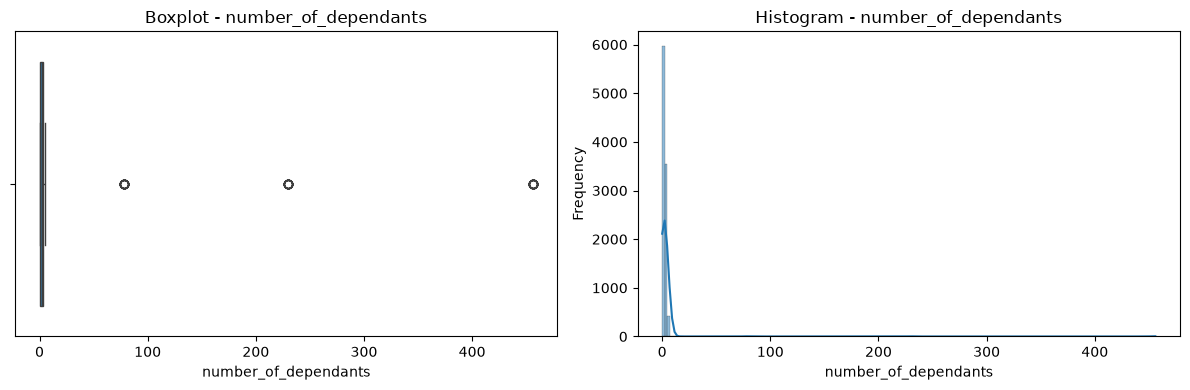

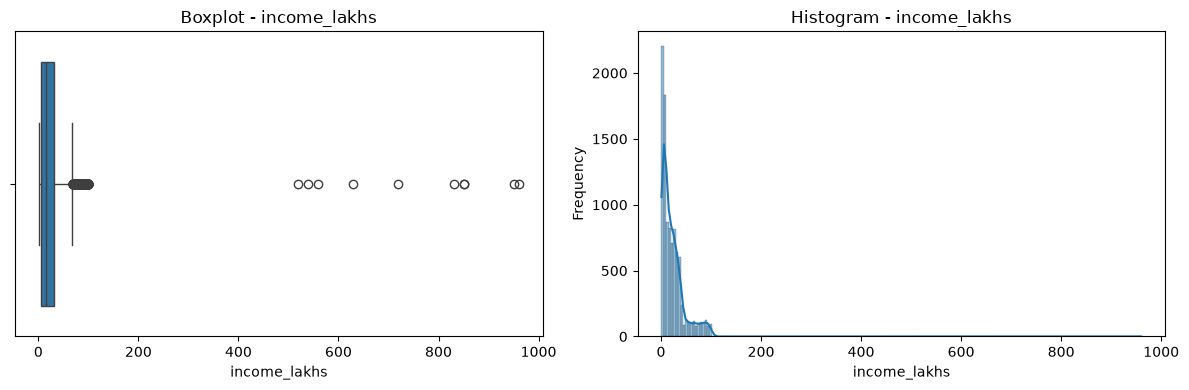

In [14]:
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f'Boxplot - {col}')
    axes[0].set_xlabel(col)

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram - {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [15]:
df = df[df['age'] < 100]
df.shape

(9915, 15)

In [16]:
def calaculate_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1 

    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lower_limit, upper_limit = calaculate_iqr(df['number_of_dependants'])
print(lower_limit, upper_limit)

-4.5 7.5


In [17]:
df = df[df['number_of_dependants'] <= upper_limit]

In [18]:
df.shape

(9868, 15)

In [19]:
income_level_IQR = calaculate_iqr(df['income_lakhs'])
income_level_IQR

(np.float64(-31.5), np.float64(68.5))

In [20]:
df = df[df['income_lakhs'] < 100]

In [21]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9828.000000,9828.000000,9828.000000,9828.000000
mean,37.775336,1.919923,22.447700,19507.564815
std,13.974675,1.502888,22.076779,8903.796128
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11767.000000
50%,37.000000,2.000000,16.000000,19324.500000
75%,50.000000,3.000000,31.000000,26505.250000
max,72.000000,5.000000,99.000000,45854.000000


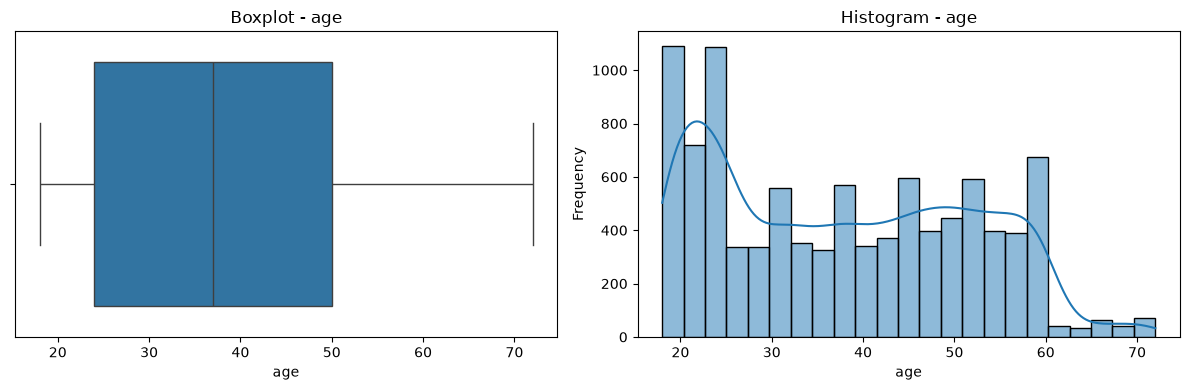

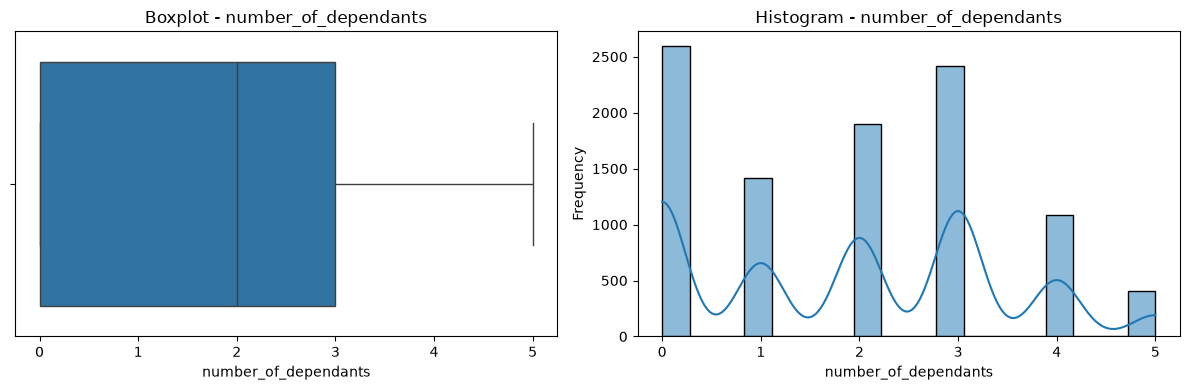

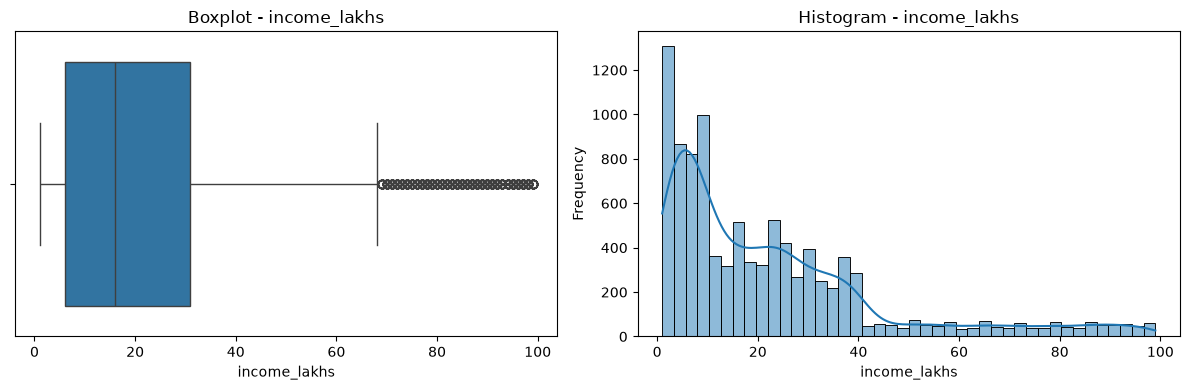

In [22]:
# Post Cleaning Graphs
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f'Boxplot - {col}')
    axes[0].set_xlabel(col)

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[1])
    axes[1].set_title(f'Histogram - {col}')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

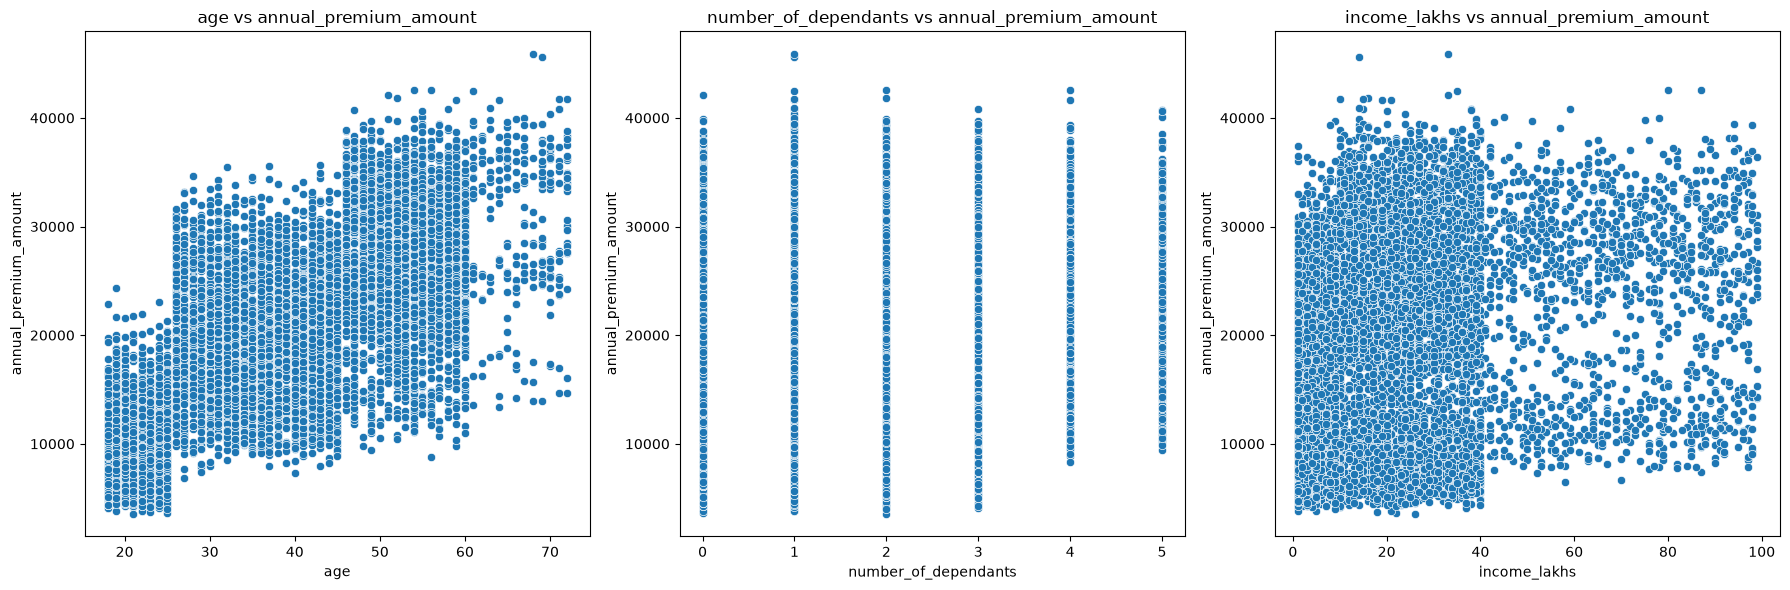

In [23]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 6))

for ax, col in zip(axes, numerical_cols):
    sns.scatterplot(x=df[col], y=df['annual_premium_amount'], ax=ax)
    ax.set_title(f'{col} vs annual_premium_amount')
    ax.set_xlabel(col)
    ax.set_ylabel('annual_premium_amount')

plt.tight_layout()
plt.show()

#### Perform EDA on Categorical column and perform encoding and feature_engineering

In [24]:
categorical_cols

Index(['gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'bmi_category', 'smoking_status', 'employment_status',
       'income_level', 'medical_history', 'insurance_plan'],
      dtype='str')

In [25]:
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}\n")

gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

region: <ArrowStringArray>
['Southeast', 'Northeast', 'Southwest', 'Northwest']
Length: 4, dtype: str

marital_status: <ArrowStringArray>
['Unmarried', 'Married']
Length: 2, dtype: str

physical_activity: <ArrowStringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

stress_level: <ArrowStringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

bmi_category: <ArrowStringArray>
['Normal', 'Overweight', 'Obesity', 'Underweight']
Length: 4, dtype: str

smoking_status: <ArrowStringArray>
['No Smoking', 'Occasional', 'Regular']
Length: 3, dtype: str

employment_status: <ArrowStringArray>
['Self-Employed', 'Freelancer', 'Salaried']
Length: 3, dtype: str

income_level: <ArrowStringArray>
['25L - 40L', '10L - 25L', '<10L', '> 40L']
Length: 4, dtype: str

medical_history: <ArrowStringArray>
[                'High blood pressure',                          'No Disease',
                             'Thyroid', 'High blood

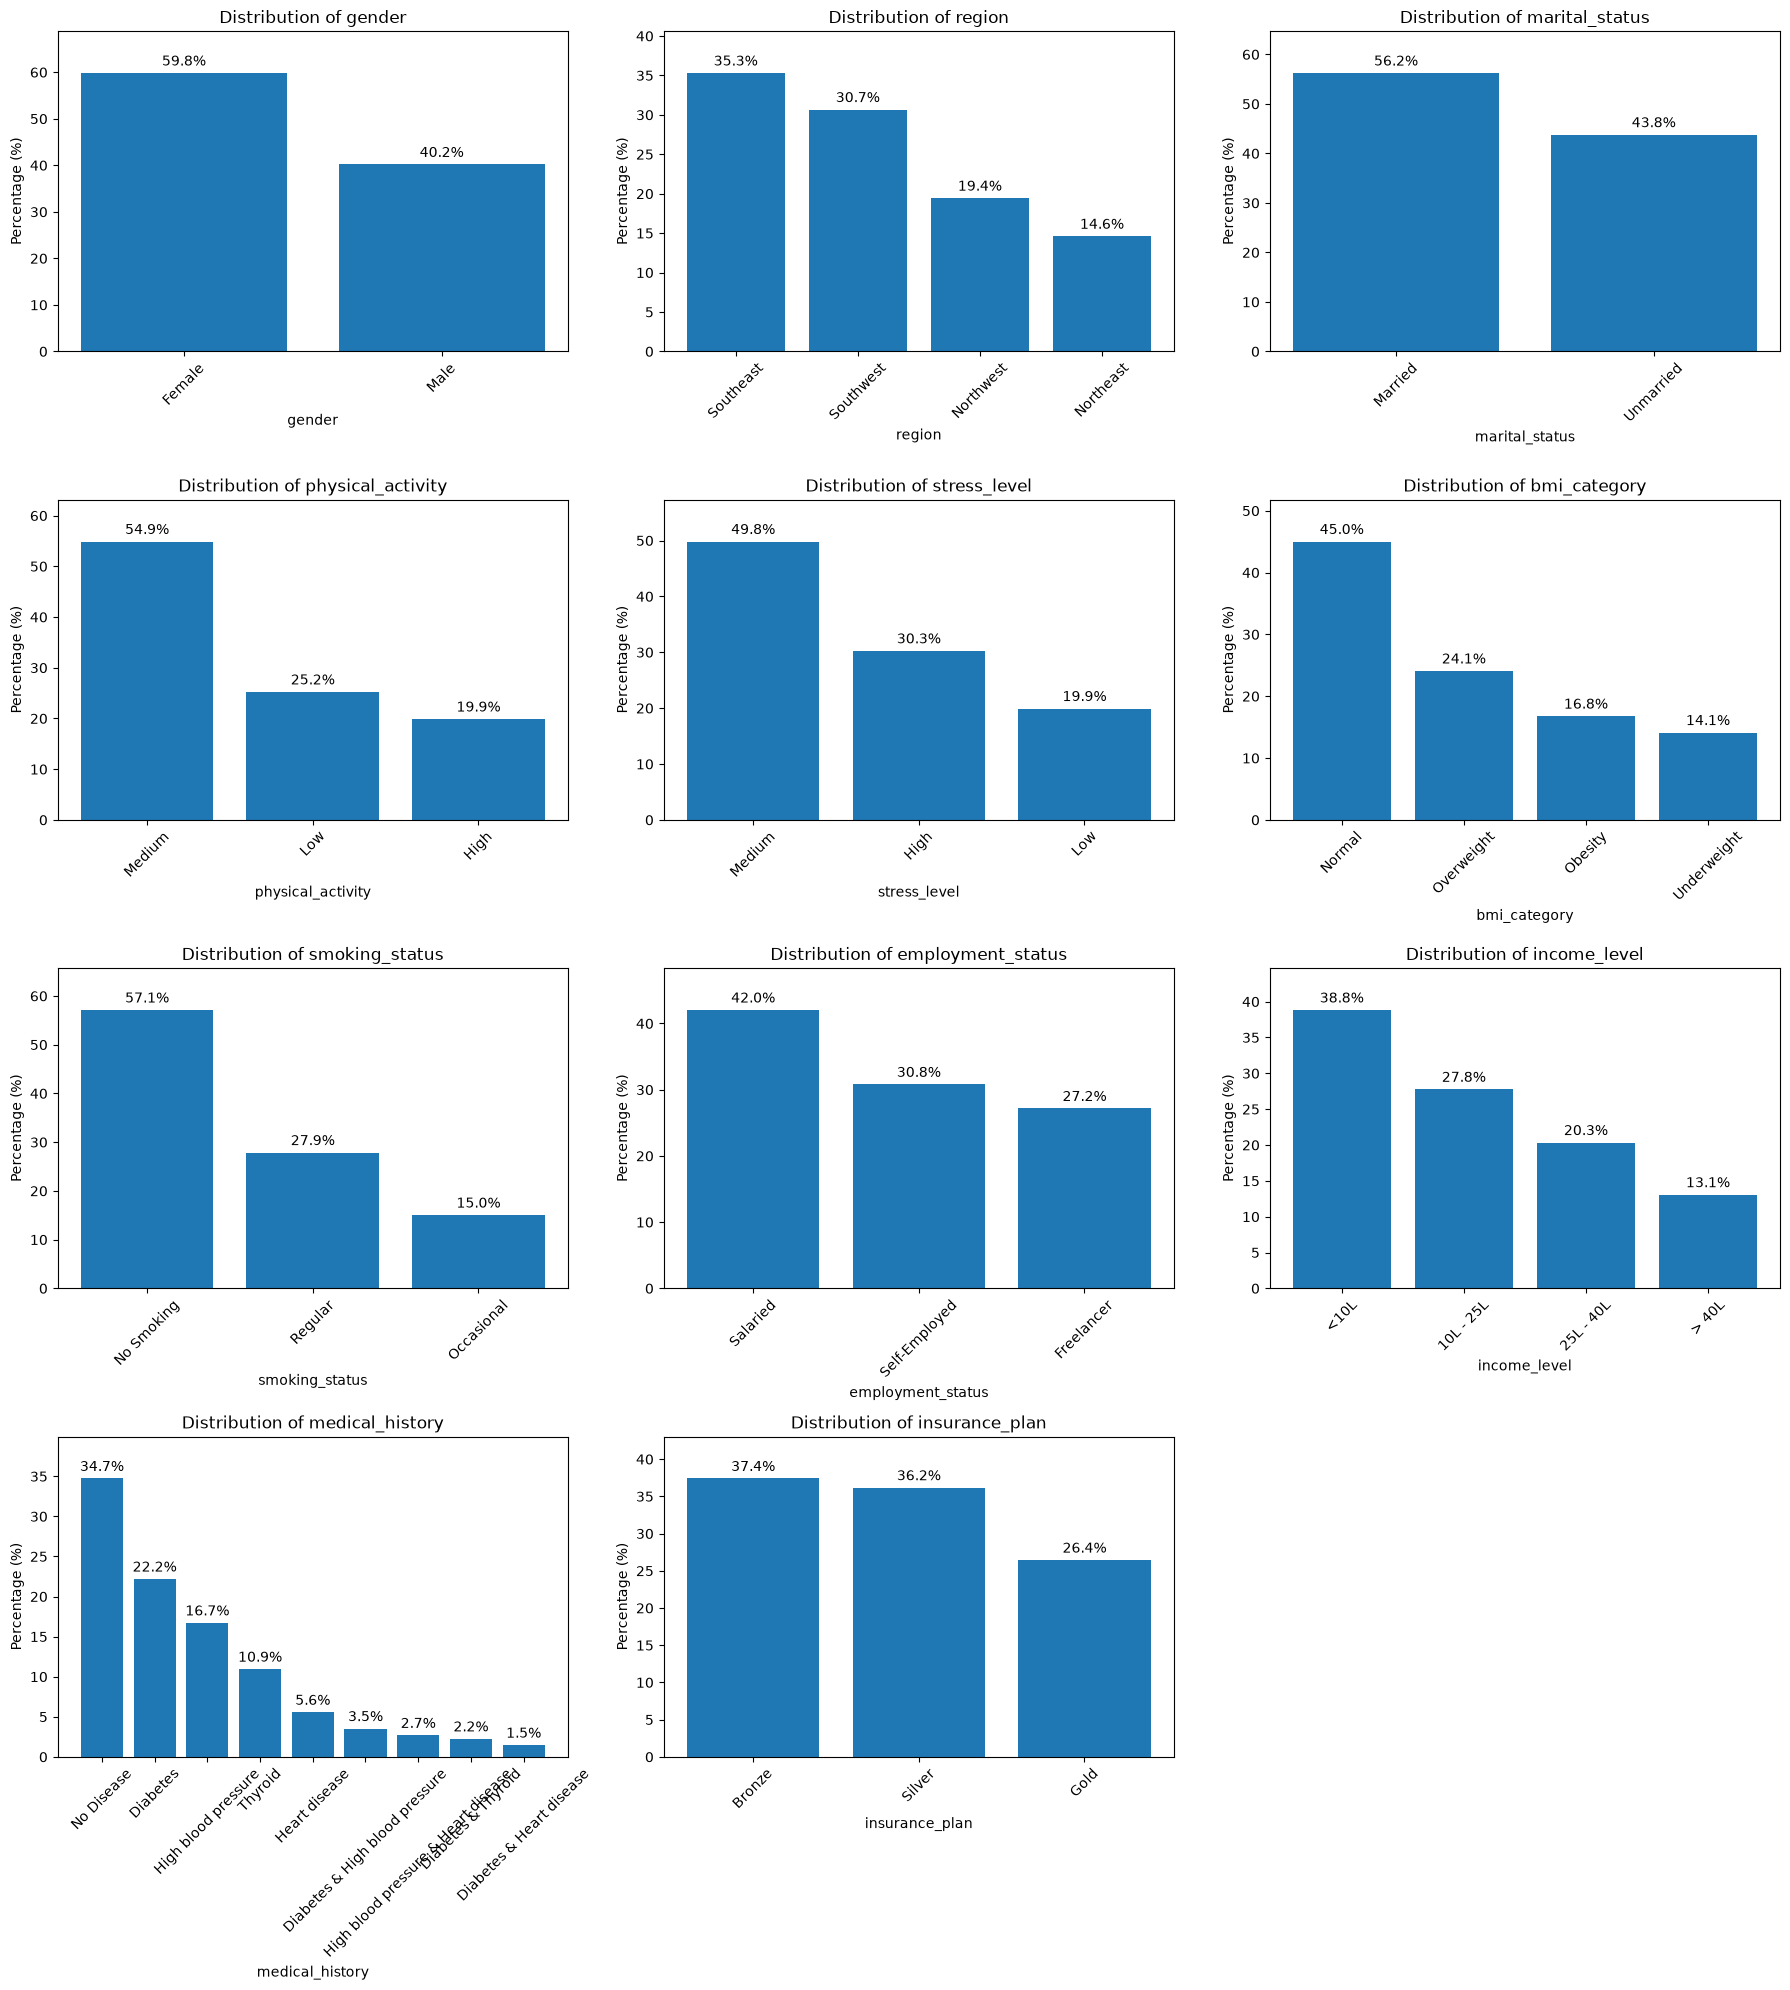

In [26]:
import math

categorical_columns = [
    'gender',
    'region',
    'marital_status',
    'physical_activity',
    'stress_level',
    'bmi_category',
    'smoking_status',
    'employment_status',
    'income_level',
    'medical_history',
    'insurance_plan'
]

n_cols = 3
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_columns):

    # Calculate percentage
    percentages = (
        df[col]
        .value_counts(normalize=True)
        .mul(100)
    )

    # Plot
    bars = axes[i].bar(
        percentages.index,
        percentages.values
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')

    axes[i].tick_params(axis='x', rotation=45)

    # Add percentage labels
    axes[i].bar_label(
        bars,
        labels=[f'{value:.1f}%' for value in percentages.values],
        padding=3
    )

    # Give some space above bars for labels
    axes[i].set_ylim(
        0,
        percentages.max() * 1.15
    )

# Hide unused subplot
for i in range(len(categorical_columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

##### Feature Engineering

In [27]:
physical_activity_mapping = {"High": 0, "Medium": 1, "Low": 4}
stress_level__mapping = {"High": 4, "Medium": 1, "Low": 0}

df['lifestyle_score'] = df.physical_activity.map(physical_activity_mapping) + df.stress_level.map(stress_level__mapping)

In [28]:
df.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,lifestyle_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,2
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,8


In [29]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure": 6,
    "thyroid": 5,
    "no disease": 0,
    "none": 0
}

df[['diesease1', 'diesease2']] = df['medical_history'].str.split(' & ', expand=True).apply(lambda x: x.str.lower())

df.fillna({
    'diesease1': 'none',
    'diesease2': 'none'
}, inplace=True)

df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
physical_activity        0
stress_level             0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
lifestyle_score          0
diesease1                0
diesease2                0
dtype: int64

In [30]:
df['diesease1'] = df.diesease1.map(risk_scores)
df['diesease2'] = df.diesease2.map(risk_scores)
df['total_risk_score'] = 0

In [31]:
df['total_risk_score'] = df.diesease1 + df.diesease2
df.head(3)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,lifestyle_score,diesease1,diesease2,total_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,2,6,0,6
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,8,0,0,0
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,5,0,0,0


##### Feature Encoding

In [ ]:
# Based on Ordinality and Nominality using Label econding for "insurance_plan_mapping" and "income_level"

income_level_mapping = {'25L - 40L': 2, '10L - 25L': 1, '<10L': 0, '> 40L': 3}
insurance_plan_mapping = {'Bronze': 0, 'Silver': 1, 'Gold': 2}

df['income_level'] = df.income_level.map(income_level_mapping)
df['insurance_plan'] = df.insurance_plan.map(insurance_plan_mapping)

df.head(1)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,lifestyle_score,diesease1,diesease2,total_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,2,37,High blood pressure,2,27944,2,6,0,6


In [33]:
cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
cols

['gender',
 'region',
 'marital_status',
 'bmi_category',
 'smoking_status',
 'employment_status']

In [34]:
df = pd.get_dummies(df, columns=cols, drop_first=True, dtype=int)

df.head()

,age,physical_activity,stress_level,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,lifestyle_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,Medium,Medium,2,2,37,High blood pressure,2,27944,2,...,1,0,1,0,0,0,0,0,0,1
1,38,Low,High,5,1,10,No Disease,1,21108,8,...,0,0,0,0,1,0,1,0,0,0
2,18,Medium,High,0,0,9,No Disease,0,8459,5,...,0,1,1,0,0,0,0,0,0,0
3,55,High,Medium,3,0,9,Thyroid,1,21685,1,...,0,0,0,0,1,0,1,0,1,0
4,22,Medium,High,2,1,13,High blood pressure & Heart disease,0,15984,5,...,1,0,1,0,0,0,0,1,0,1


In [35]:
df = df.drop(['physical_activity', 'stress_level', 'medical_history', 'diesease1', 'diesease2'], axis=1)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,lifestyle_score,total_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,2,2,37,2,27944,2,6,0,0,1,0,1,0,0,0,0,0,0,1
1,38,5,1,10,1,21108,8,0,0,0,0,0,0,0,1,0,1,0,0,0
2,18,0,0,9,0,8459,5,0,0,0,0,1,1,0,0,0,0,0,0,0


##### Feature Scaling and Normalization

In [36]:
from sklearn.preprocessing import MinMaxScaler

X = df.drop('annual_premium_amount', axis=1)
y = df['annual_premium_amount']

scaler = MinMaxScaler()
cols_to_scale = ['age', 'number_of_dependants', 'income_level', 'income_lakhs', 'insurance_plan', 'lifestyle_score', 'total_risk_score']
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

#### Feature Selection using Correlation and VIF

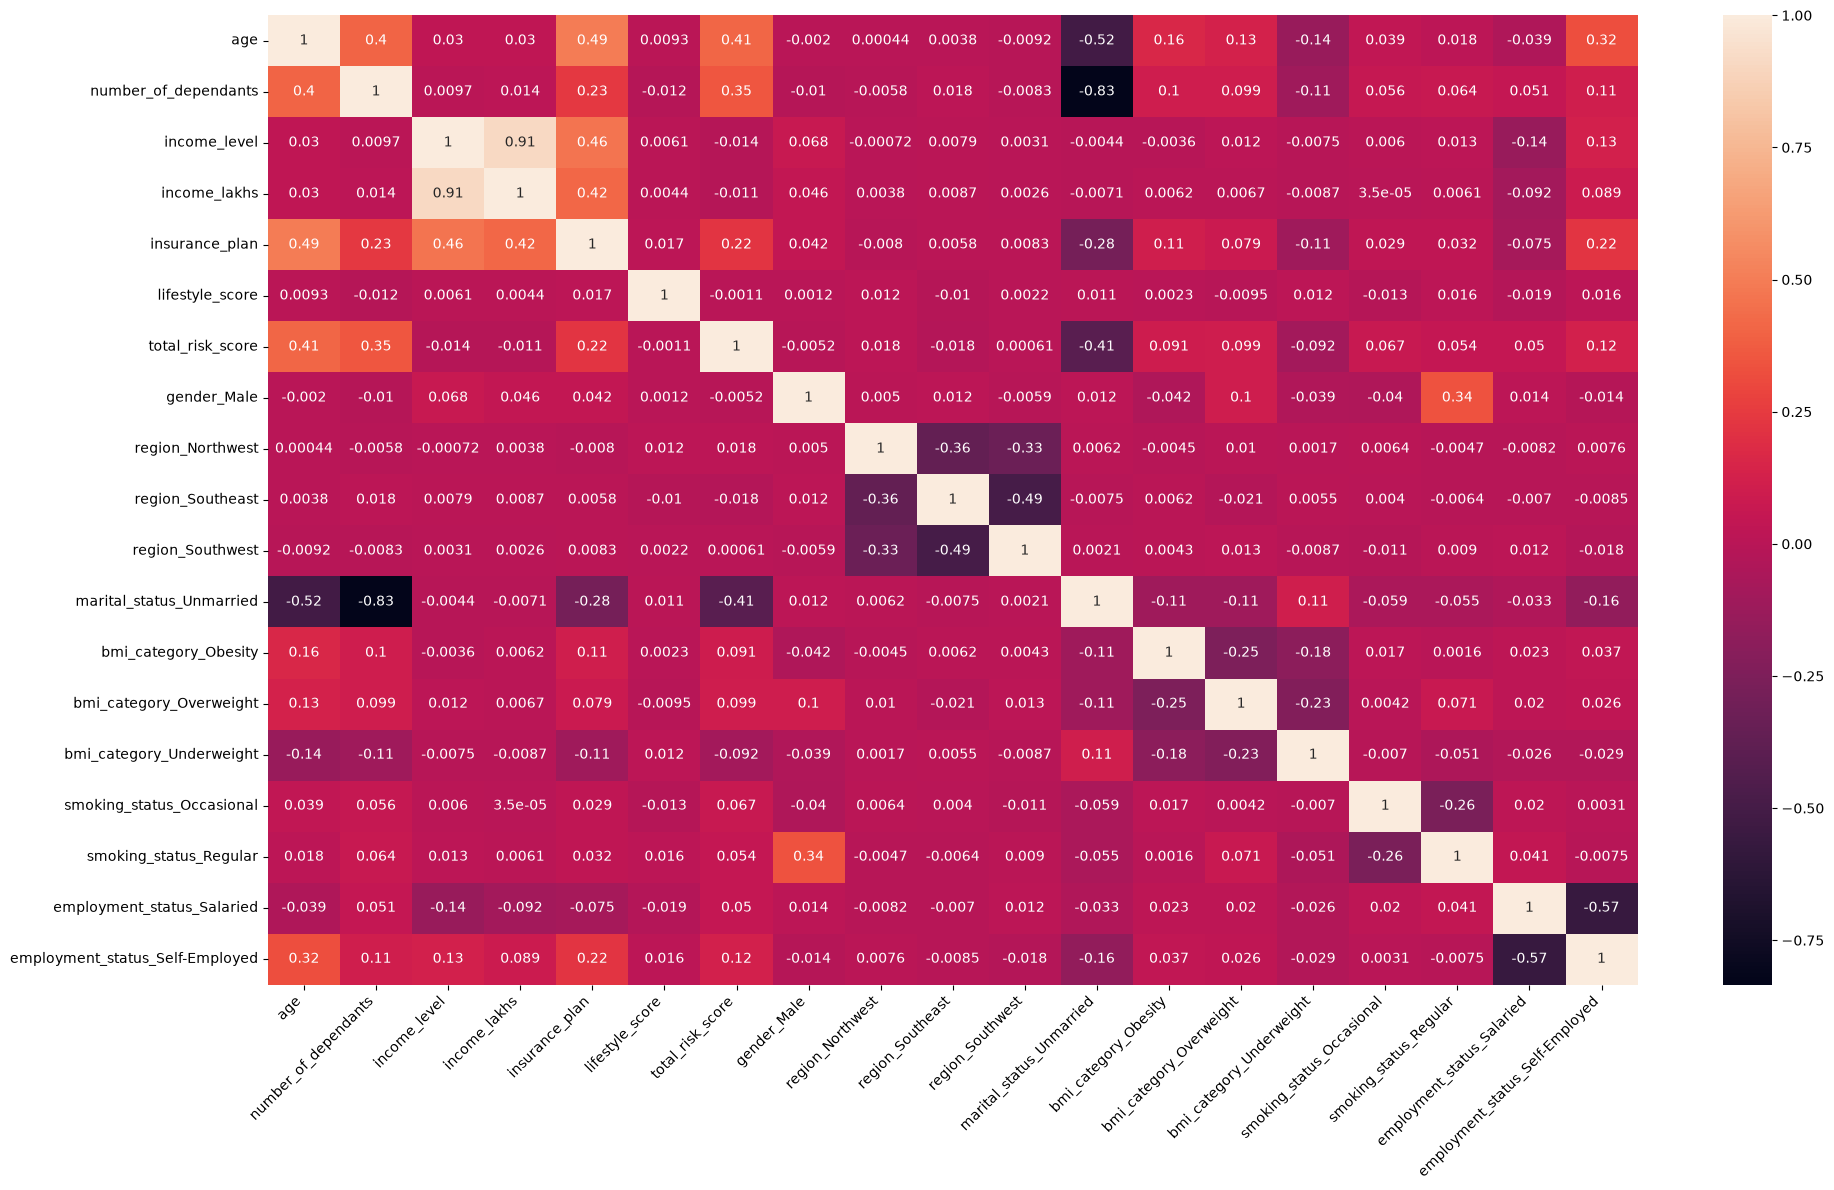

In [37]:
cm = X.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calaculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])] 
    return vif_df

In [39]:
calaculate_vif(X)

,Columns,VIF
0,age,5.552317
1,number_of_dependants,5.315618
2,income_level,12.771925
3,income_lakhs,11.237020
4,insurance_plan,4.132476
5,lifestyle_score,3.110017
6,total_risk_score,3.002788
7,gender_Male,1.912686
8,region_Northwest,2.079665
9,region_Southeast,2.950385


In [40]:
# Since, "Income_level" & "Income_lakhs" are highly correlated.

calaculate_vif(X.drop('income_lakhs', axis=1))

,Columns,VIF
0,age,5.549844
1,number_of_dependants,5.314974
2,income_level,2.796708
3,insurance_plan,4.131503
4,lifestyle_score,3.110011
5,total_risk_score,3.002752
6,gender_Male,1.910204
7,region_Northwest,2.078881
8,region_Southeast,2.949687
9,region_Southwest,2.678635


In [41]:
X.drop('income_lakhs', axis=1, inplace=True)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=32)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

lr_test_score = model_lr.score(X_test, y_test)
lr_train_score = model_lr.score(X_train, y_train)
lr_mse = mean_squared_error(y_test, y_pred_lr)

print({
    "Linear Regression": {
        "Train_Score": lr_train_score,
        "Test_Score": lr_test_score,
        "MSE": lr_mse
    }
})

{'Linear Regression': {'Train_Score': 0.9581951906914944, 'Test_Score': 0.9575802174047441, 'MSE': 3230590.4915038724}}


In [43]:
model_lr.intercept_

np.float64(3901.1475472674065)

In [44]:
feature_importances = model_lr.coef_
feature_importances

array([10652.86350648,  -736.36485068,  -300.07177113, 13355.64547989,
        4730.75798271,  6559.76143985,    21.1431581 ,    36.49935284,
          88.85218441,   -14.79305917,  -838.85837399,  4154.43108687,
        2086.74827436,   388.0658744 ,  1165.50088864,  3098.1693406 ,
          22.96719624,   336.77789985])

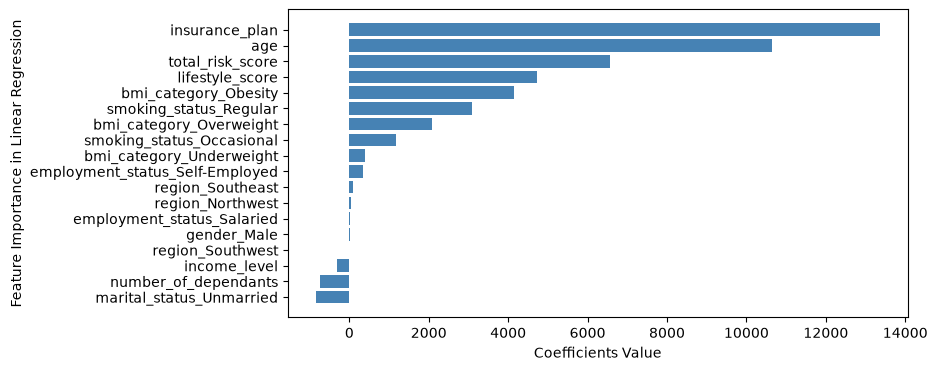

In [45]:
def plot_feature_importance(feature_importances, test_data):
    coef_df = pd.DataFrame(feature_importances, index=test_data.columns, columns=['Coefficients'])
    coef_df = coef_df.sort_values(by="Coefficients", ascending=True)

    plt.figure(figsize=(8, 4))
    plt.barh(coef_df.index, coef_df['Coefficients'], color="steelblue")
    plt.xlabel('Coefficients Value')
    plt.ylabel('Feature Importance in Linear Regression')
    plt.show()

plot_feature_importance(feature_importances, X_test)

In [46]:
model_xgb = XGBRegressor(n_estimators=50, max_depth=5)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

xgb_test_score = model_xgb.score(X_test, y_test)
xgb_train_score = model_xgb.score(X_train, y_train)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)

print({
    "XGBoost Regression": {
        "Train_Score": xgb_train_score,
        "Test_Score": xgb_test_score,
        "MSE": xgb_mse
    }
})

{'XGBoost Regression': {'Train_Score': 0.9960965514183044, 'Test_Score': 0.994378387928009, 'MSE': 428129.96875}}


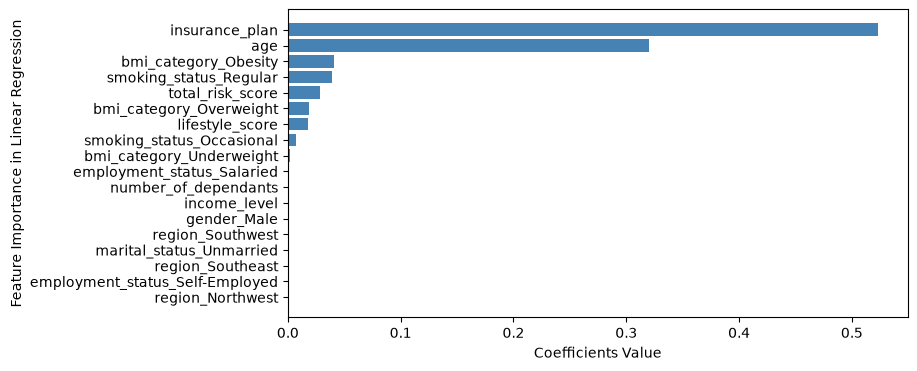

In [47]:
plot_feature_importance(model_xgb.feature_importances_, X_test)

#### Error Analysis

In [48]:
y_pred = model_xgb.predict(X_test)
residuals = y_test - y_pred
residuals_pct = (residuals * 100) / y_test

residuals_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residuals": residuals,
    "Residual_pct": residuals_pct
})

residuals_df

,Actual,Predicted,Residuals,Residual_pct
8734,32896,32919.347656,-23.347656,-0.070974
4581,5855,5826.880371,28.119629,0.480267
1594,20758,20888.890625,-130.890625,-0.630555
7644,23671,24280.992188,-609.992188,-2.576960
5881,21247,21890.166016,-643.166016,-3.027091
...,...,...,...,...
2625,13388,12393.685547,994.314453,7.426908
8009,20854,21578.128906,-724.128906,-3.472374
71,11911,11310.517578,600.482422,5.041411
3498,18743,19811.808594,-1068.808594,-5.702441


<Axes: xlabel='Residual_pct', ylabel='Count'>

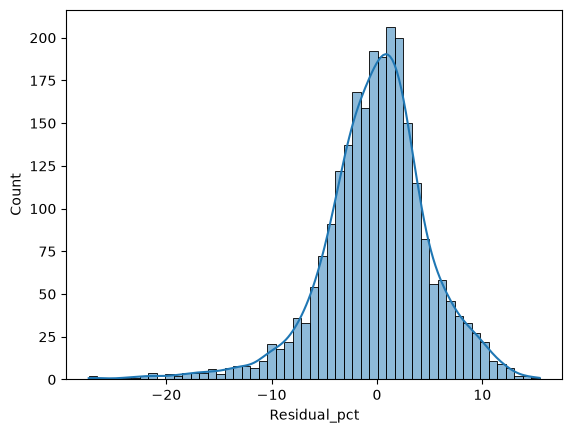

In [49]:
sns.histplot(residuals_df['Residual_pct'], kde=True)

In [50]:
errors = residuals_df[abs(residuals_df['Residual_pct']) > 10]
errors

,Actual,Predicted,Residuals,Residual_pct
7302,5291,5875.733887,-584.733887,-11.051482
7124,6764,7662.931641,-898.931641,-13.289941
6644,8560,9634.364258,-1074.364258,-12.550984
9240,4606,5424.965820,-818.965820,-17.780413
3688,8416,7508.753906,907.246094,10.780015
...,...,...,...,...
5424,11795,13049.326172,-1254.326172,-10.634389
1276,13728,15103.183594,-1375.183594,-10.017363
9014,10526,9441.458984,1084.541016,10.303449
6778,7694,8565.599609,-871.599609,-11.328303


In [51]:
print(f"Error Pct: {errors.shape[0] / residuals_df.shape[0]}")

Error Pct: 0.05657305657305657


In [52]:
errors_index = errors.index

errors_df = X_test.loc[errors_index]
errors_df['income_lakhs'] = 0
errors_df[cols_to_scale] = scaler.inverse_transform(errors_df[cols_to_scale])

In [53]:
errors_df['age'].describe()

count    139.000000
mean      22.079137
std        3.259467
min       18.000000
25%       19.000000
50%       22.000000
75%       24.000000
max       35.000000
Name: age, dtype: float64